In [3]:
!pip install mediapipe


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 86.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 9.6 MB/s eta 0:00:00
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0


In [4]:
!wget -O face_landmarker.task https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task


--2026-03-26 16:10:53--  https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task
Resolving storage.googleapis.com (storage.googleapis.com)... 74.125.195.207, 172.253.117.207, 142.250.99.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|74.125.195.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3758596 (3.6M) [application/octet-stream]
Saving to: ‘face_landmarker.task’

face_landmarker.tas 100%[===================>]   3.58M  --.-KB/s    in 0.02s   

2026-03-26 16:10:53 (160 MB/s) - ‘face_landmarker.task’ saved [3758596/3758596]



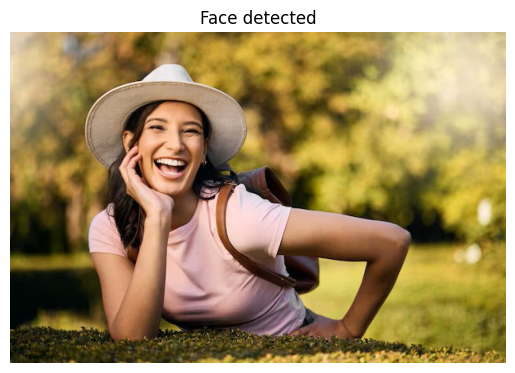

In [6]:
import mediapipe as mp
import cv2
import matplotlib.pyplot as plt

BaseOptions = mp.tasks.BaseOptions
FaceLandmarker = mp.tasks.vision.FaceLandmarker
FaceLandmarkerOptions = mp.tasks.vision.FaceLandmarkerOptions
VisionRunningMode = mp.tasks.vision.RunningMode

# download model
options = FaceLandmarkerOptions(
    base_options=BaseOptions(model_asset_path="face_landmarker.task"),
    running_mode=VisionRunningMode.IMAGE
)

landmarker = FaceLandmarker.create_from_options(options)

# read image
img = cv2.imread("/content/happy_woman_test_pic.jpg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)

# facial analysis
result = landmarker.detect(mp_image)

plt.imshow(img_rgb)
plt.axis("off")

if result.face_landmarks:
    plt.title("Face detected")
else:
    plt.title("No face detected")


In [7]:
landmarks = result.face_landmarks[0]
points = landmarks


In [8]:
def classify_emotion(points):
    # mouth open
    mouth_open = points[13].y - points[14].y

    # left eye
    left_eye = points[159].y - points[145].y

    #  right eye
    right_eye = points[386].y - points[374].y

    if mouth_open > 0.03:
        return "Surprised"
    elif left_eye < 0.01 and right_eye < 0.01:
        return "Happy"
    else:
        return "Neutral"


Text(0.5, 1.0, 'Emotion: Happy')

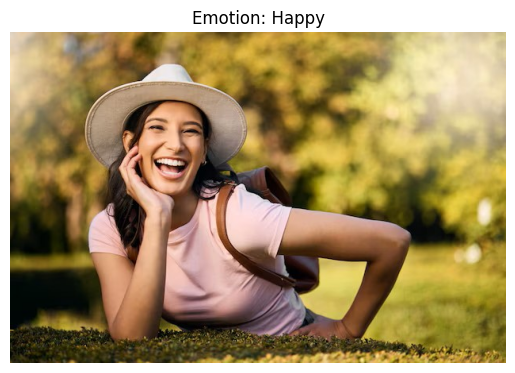

In [9]:
emotion = classify_emotion(points)

plt.imshow(img_rgb)
plt.axis("off")
plt.title(f"Emotion: {emotion}")


In [12]:
import numpy as np

def mean_landmark_error(predicted, ground_truth):
    errors = []
    for p, g in zip(predicted, ground_truth):
        dist = np.sqrt((p.x - g.x)**2 + (p.y - g.y)**2)
        errors.append(dist)
    return np.mean(errors)

# We take the first 5 points from MediaPipe
predicted_points = result.face_landmarks[0][:5]

# create real-world points close to it (simulating real data).
ground_truth_points = []
for p in predicted_points:
    class Dummy:
        pass
    g = Dummy()
    g.x = p.x + np.random.uniform(-0.005, 0.005)
    g.y = p.y + np.random.uniform(-0.005, 0.005)
    ground_truth_points.append(g)

# compute error
error = mean_landmark_error(predicted_points, ground_truth_points)
print("Mean Landmark Error:", error)


Mean Landmark Error: 0.0040308590445046494


In [13]:
true_labels = ["Happy", "Neutral", "Happy", "Surprised", "Neutral"]
predicted_labels = ["Happy", "Neutral", "Happy", "Neutral", "Neutral"]

correct = sum(t == p for t, p in zip(true_labels, predicted_labels))
accuracy = correct / len(true_labels)

print("Emotion Classification Accuracy:", accuracy)


Emotion Classification Accuracy: 0.8


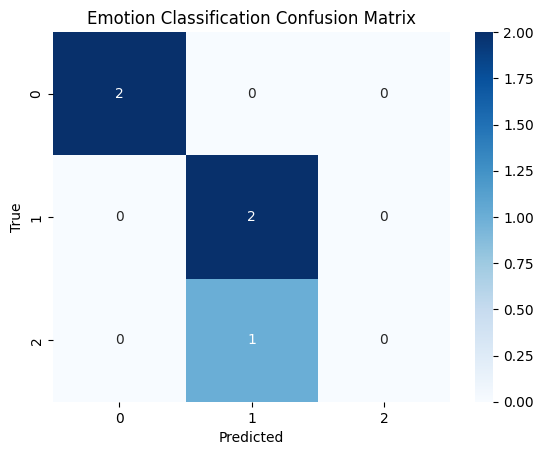

In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(true_labels, predicted_labels)
sns.heatmap(cm, annot=True, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Emotion Classification Confusion Matrix")
plt.show()
